In [1]:
import pickle
import numpy as np
import yaml
import os
from matplotlib import pyplot as plt
import pysindy as ps

# read in all the data
trial_folder = 'C:\\Users\\Joseph Sullivan\\Documents\\hsa_hopper_control\\data\\hsa_identification\\2024-06-14_1718320925'
with open(os.path.join(trial_folder, 'experiment_config.yaml'), 'r') as f:
    experiment_config = yaml.load(f, yaml.Loader)
with open(os.path.join(trial_folder, 'hardware_config.yaml'), 'r') as f:
    hardware_config = yaml.load(f, yaml.Loader)
with open(os.path.join(trial_folder, 'data.pickle'), 'rb') as f:
     data = pickle.load(f)

In [2]:
import pysindy as ps
def calculate_dynamics(x,t):
    dt = ps.FiniteDifference(2,1,0,drop_endpoints=False)
    ddt = ps.FiniteDifference(2,2,0,drop_endpoints=False)
    xdot = dt._differentiate(x,t,)
    xddot = ddt._differentiate(x,t)
    return xdot, xddot

In [29]:
# downsample the data and fit the dynamics
skip = 10
x = [np.array(arr[len(arr)//10:9*len(arr)//10:skip]) for arr in data['motor_angle']]
tau = [np.array(arr[len(arr)//10:9*len(arr)//10:skip]) for arr in data['motor_torque']]
l = [np.array(arr[len(arr)//10:9*len(arr)//10:skip]) for arr in data['hsa_len']]
ldot = []
lddot = []
dldx = [np.array(arr[len(arr)//10:9*len(arr)//10:skip]) for arr in data['dldtheta']]
t = [np.array(arr[len(arr)//10:9*len(arr)//10:skip]) for arr in data['times']]
psi = data['hsa_angle']
xdot = []
xddot = []
for i in range(len(x)):
    _xdot, _xddot = calculate_dynamics(x[i],t[i])
    xdot.append(_xdot)
    xddot.append(_xddot)
    _ldot, _lddot = calculate_dynamics(l[i],t[i])
    ldot.append(_ldot)
    lddot.append(_lddot)

In [201]:
"""
Experimental - fitting two potential functions and blending them together with a logistic function
"""

from scipy.optimize import minimize
from scipy.optimize import LinearConstraint
from hsa_hopper.hsa_model import HSAPotential

# function to do the model optimization
def governing_equation_lstsq(s, a, y_c, y_d, kind=HSAPotential.LINEAR):
    if kind == HSAPotential.LINEAR:
        model = HSAPotential(0,0,0, None, None, None, None, a, s, kind=kind)
    else:
        w_c = np.zeros(y_c.shape[1])
        w_d = np.zeros(y_d.shape[1])
        model = HSAPotential(0, 0, 0,w_c, y_c, w_d, y_d, a, s, kind=kind)
    N_samples = [len(x[i]) for i in range(len(x))]
    N = model.num_params()
    M = sum(N_samples)
    A = np.zeros((M,2 + N))
    b = np.zeros((M))
    for i in range(len(x)):
        start = sum(N_samples[:i])
        stop = start+N_samples[i]
        for row in range(start,stop):
            b[row] = tau[i][row-start]
            A[row,0] = xddot[i][row-start]
            A[row,1] = xdot[i][row-start]
            A[row,2] = dldx[i][row-start]*l[i][row-start]
            A[row,3] = dldx[i][row-start]
            A[row,4] = dldx[i][row-start]*ldot[i][row-start]
            if model.kind != HSAPotential.LINEAR:
                N_c = model.w_c.shape[0]
                N_d = model.w_d.shape[0]
                z = np.array((l[i][row-start],psi[i]))
                zdot = np.array((ldot[i][row-start],0))
                for j in range(w_c.shape[0]):
                    A[row,5+j] = dldx[i][row-start]*model.dkc(z,j)[0]
                for j in range(N_d):
                    A[row,5+N_c+j] = dldx[i][row-start]*model.dkd(z,zdot,j)[0]

    ATA = A.T@A
    ATb = A.T@b
    bTb = np.dot(b,b)
    f = lambda x: x.T@ATA@x+bTb-2*x.T@ATb
    jac = lambda x: 2*ATA@x-2*ATb

    # next constraints - enforce positive weights
    # and positive definiteness of stiffness at collocation points
    C = np.zeros((5,2+N))
    C[0,0] = 1 # bounds on J_x ( lumped inertia )
    C[1,1] = 1 # bounds on b_x ( motor dissipation coefficient )
    C[2,2] = 1 # bounds on K (HSA linear spring rate)
    C[3,3] = 1 # bounds on F0 (HSA linear spring preload)
    C[4,4] = 1 # bounds on b (HSA linear disspation term)
    lb = np.array([3e-3,3e-3,0,-100,0])
    ub = np.array([5e-3,4e-3,1000,100,100])

    constraints = [LinearConstraint(C,lb=lb,ub=ub)]

    x0 = np.zeros(2+N)
    result = minimize(f, x0, 
                    jac=jac, 
                    constraints=constraints, 
                    method='SLSQP',
                    options={'maxiter' : 6000})
    result.A = A
    result.b = b
    result.sample_size = b.shape[0]
    result.num_params = model.num_params()
    result.J_x = result.x[0]
    result.b_x = result.x[1]
    model.K = result.x[2]
    model.F0 = result.x[3]
    model.b = result.x[4]
    if model.kind != HSAPotential.LINEAR:
        N_c = model.w_c.shape[0]
        N_d = model.w_d.shape[0]
        model.w_c = result.x[5:5+N_c]
        model.w_d = result.x[5+N_c:]
    result.model = model
    result.r_sqr = 1-result.fun/np.sum((b-np.average(b))**2)
    result.r_sqr_adj = 1-(1-result.r_sqr)*(result.sample_size-1)/(result.sample_size-result.num_params-1)
    result.mse = result.fun/result.sample_size
    result.rmse = np.sqrt(result.mse)
    result.bic = result.sample_size*np.log(result.mse)+result.num_params*np.log(result.sample_size)
    result.errors = A@result.x-b
    return result 
    

In [202]:
y_c = y_d = None
linear_fit = governing_equation_lstsq(0,0,None,None)
print(linear_fit.r_sqr)
linear_fit.model.b

0.8791175245039631


14.636977165051139

In [203]:
# choosing an optimal (s) for a linear damping model according to the number of basis functions
from scipy.optimize import minimize_scalar
def optimal_classical_damp_model(M, s_min, s_max, maxiter):
    l_min = min([min(l[i]) for i in range(len(psi))])
    l_max = max([max(l[i]) for i in range(len(psi))])
    psi_min = min(psi)
    psi_max = max(psi)
    y = np.zeros((2,M**2))
    l_values = np.linspace(l_min,l_max,M)
    psi_values = np.linspace(psi_min,psi_max,M)
    for i in range(M):
        for j in range(M):
            y[0,i+M*j] = l_values[i]
            y[1,i+M*j] = psi_values[j]
    func = lambda s: governing_equation_lstsq(s,0,y,np.zeros((0,0)),kind=HSAPotential.GENERALIZED).fun
    result = minimize_scalar(func, method='bounded', bounds=(s_min, s_max), options={'maxiter': maxiter})
    return governing_equation_lstsq(result.x,0,y,np.zeros((0,0)),kind=HSAPotential.GENERALIZED)

# sweep through different values of Nl, plot and fit a line
M_values = [3,4,5,6,7,8,9,10]
classical_models = []
for M in M_values:
    print(M)
    result = optimal_classical_damp_model(M,1.,3.,200)
    classical_models.append(result)

3
4
5
6
7
8
9
10


In [204]:
# now for a_values with nonlinear damping
def optimal_generalized_damp_model(M, s0, s1, maxiter):
    l_min = min([min(l[i]) for i in range(len(psi))])
    l_max = max([max(l[i]) for i in range(len(psi))])
    psi_min = min(psi)
    psi_max = max(psi)
    y = np.zeros((2,M**2))
    l_values = np.linspace(l_min,l_max,M)
    psi_values = np.linspace(psi_min,psi_max,M)
    for i in range(M):
        for j in range(M):
            y[0,i+M*j] = l_values[i]
            y[1,i+M*j] = psi_values[j]
    func = lambda s: governing_equation_lstsq(s,1,y,y,kind=HSAPotential.GENERALIZED).fun
    result = minimize_scalar(func, method='bounded', bounds=(s0, s1), options={'maxiter': maxiter})
    return governing_equation_lstsq(result.x,1,y,y,kind=HSAPotential.GENERALIZED)

generalized_models = []
M_values = [3,4,5,6,7]
for i,M in enumerate(M_values):
    print(M)
    result = optimal_generalized_damp_model(M,1.,5.,30)
    generalized_models.append(result)

3
4
5
6
7


In [205]:
# def optimal_nonlinear_damp_model(M, s, a0, a1, maxiter):
#     l_min = min([min(l[i]) for i in range(len(psi))])
#     l_max = max([max(l[i]) for i in range(len(psi))])
#     psi_min = min(psi)
#     psi_max = max(psi)
#     y = np.zeros((2,M**2))
#     l_values = np.linspace(l_min,l_max,M)
#     psi_values = np.linspace(psi_min,psi_max,M)
#     for i in range(M):
#         for j in range(M):
#             y[0,i+M*j] = l_values[i]
#             y[1,i+M*j] = psi_values[j]
#     func = lambda a: governing_equation_lstsq(s,a,y,y,kind=HSAPotential.NONLINEAR).fun
#     result = minimize_scalar(func, method='bounded', bounds=(a0, a1), options={'maxiter': maxiter})
#     return governing_equation_lstsq(s,result.x,y,y,kind=HSAPotential.NONLINEAR)
def optimal_nonlinear_damp_model(M, a, s0, s1, maxiter):
    l_min = min([min(l[i]) for i in range(len(psi))])
    l_max = max([max(l[i]) for i in range(len(psi))])
    psi_min = min(psi)
    psi_max = max(psi)
    y = np.zeros((2,M**2))
    l_values = np.linspace(l_min,l_max,M)
    psi_values = np.linspace(psi_min,psi_max,M)
    for i in range(M):
        for j in range(M):
            y[0,i+M*j] = l_values[i]
            y[1,i+M*j] = psi_values[j]
    func = lambda s: governing_equation_lstsq(s,a,y,y,kind=HSAPotential.NONLINEAR).fun
    result = minimize_scalar(func, method='bounded', bounds=(s0, s1), options={'maxiter': maxiter})
    return governing_equation_lstsq(result.x,a,y,y,kind=HSAPotential.NONLINEAR)

nonlinear_models = []
M_values = [3,4,5,6,7]
for i,M in enumerate(M_values):
    print(M)
    generalized_result = generalized_models[i]
    s_value = generalized_result.model.s
    result = optimal_nonlinear_damp_model(M,1.,1.,5.,30)
    nonlinear_models.append(result)

3
4
5
6
7


In [206]:
# M = 7
# result = optimal_nonlinear_damp_model(M,generalized_models[-1].model.s,.1,5.,30)
# nonlinear_models.append(result)

In [207]:
# fit chi-squared distributions to models, packall information into dataframe for plotting
import pandas as pd
data_frame = pd.DataFrame(columns=['SOS','RSQR','RSQR_ADJ','RMSE','N', 'M', 'BIC', 's','a','kind'])
rows = []
for result in classical_models:
    errors = result.errors
    rows.append({
        'SOS' : result.fun,
        'RSQR' : result.r_sqr,
        'RSQR_ADJ' : result.r_sqr_adj,
        'RMSE' : result.rmse,
        'N' : result.num_params,
        'M' : int(np.sqrt(result.num_params-1)),
        'BIC' : result.bic,
        'AIK' : 2*result.num_params + result.sample_size*np.log(result.fun),
        's' : result.model.s,
        'a' : result.model.a,
        'kind' : 'classical'
    })
for result in generalized_models:
    errors = result.errors
    rows.append({
        'SOS' : result.fun,
        'RSQR' : result.r_sqr,
        'RSQR_ADJ' : result.r_sqr_adj,
        'RMSE' : result.rmse,
        'N' : result.num_params,
        'M' : int(np.sqrt((result.num_params-1)/2)),
        'BIC' : result.bic,
        'AIK' : 2*result.num_params + result.sample_size*np.log(result.fun),
        's' : result.model.s,
        'a' : result.model.a,
        'kind' : 'generalized'
    })
for result in nonlinear_models:
    errors = result.errors
    rows.append({
        'SOS' : result.fun,
        'RSQR' : result.r_sqr,
        'RSQR_ADJ' : result.r_sqr_adj,
        'RMSE' : result.rmse,
        'N' : result.num_params,
        'M' : int(np.sqrt((result.num_params-1)/2)),
        'BIC' : result.bic,
        'AIK' : 2*result.num_params + result.sample_size*np.log(result.fun),
        's' : result.model.s,
        'a' : result.model.a,
        'kind' : 'nonlinear'
    })
total_df= pd.DataFrame(rows)
df1 = total_df[total_df['N']>0]
df2 = total_df[3<=total_df['M']]
df2 = total_df[df2['M']<=7]

In [208]:
print(total_df['s'])
print(total_df['a'])

0     1.352819
1     2.998152
2     2.589399
3     1.925123
4     1.806123
5     1.389700
6     1.461136
7     1.474866
8     1.766745
9     3.110635
10    2.680173
11    1.990629
12    1.785166
13    1.572981
14    2.141930
15    2.011313
16    1.833929
17    1.407239
Name: s, dtype: float64
0     0.0
1     0.0
2     0.0
3     0.0
4     0.0
5     0.0
6     0.0
7     0.0
8     1.0
9     1.0
10    1.0
11    1.0
12    1.0
13    1.0
14    1.0
15    1.0
16    1.0
17    1.0
Name: a, dtype: float64


In [209]:
# configure matplotlib rcparams for style
import matplotlib.pyplot as plt
from cycler import cycler

# Set the font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# Define a custom color cycle of 10 colors
colorblind_friendly_colors = ['#6a0dad', '#2ca02c', '#e2a000', '#1f77b4', '#ff7f0e', '#d62728']

# Update the default color cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colorblind_friendly_colors)

Text(0.5, 1.0, 'R^2')

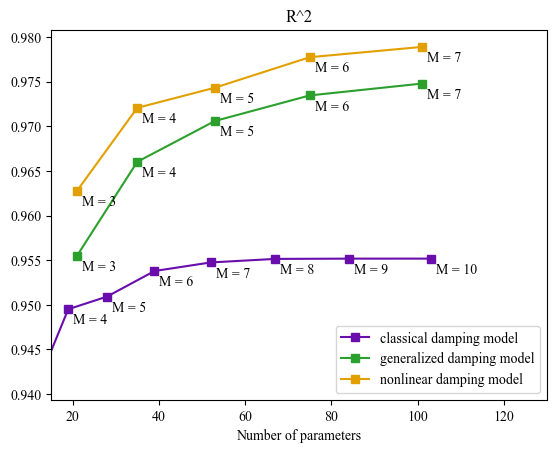

In [210]:
fig, ax = plt.subplots()
sub_df = df1[df1['kind'] == 'classical']
N1 = sub_df['N'].to_numpy()
M1 = sub_df['M'].to_numpy()
y1 = sub_df['RSQR'].to_numpy()
ax.plot(N1, y1, label='classical damping model',marker='s')
sub_df = df1[df1['kind'] == 'generalized']
N2 = sub_df['N'].to_numpy()
M2 = sub_df['M'].to_numpy()
y2 = sub_df['RSQR'].to_numpy()
ax.plot(N2, y2, label='generalized damping model',marker='s')
sub_df = df1[df1['kind'] == 'nonlinear']
N3 = sub_df['N'].to_numpy()
M3 = sub_df['M'].to_numpy()
y3 = sub_df['RSQR'].to_numpy()
ax.plot(N3,y3, label='nonlinear damping model',marker='s')

for i, N in enumerate(N1):
    ax.annotate(f'M = {M1[i]}', (N1[i],y1[i]), xytext=(5,-15), xycoords='data', textcoords='offset pixels')
for i, N in enumerate(N2):
    ax.annotate(f'M = {M2[i]}', (N2[i],y2[i]), xytext=(5,-15), xycoords='data', textcoords='offset pixels')
for i, N in enumerate(N3):
    ax.annotate(f'M = {M3[i]}', (N3[i],y3[i]), xytext=(5,-15), xycoords='data', textcoords='offset pixels')
ax.set_xlim(15,130)
plt.legend()
plt.xlabel('Number of parameters')
plt.title('R^2')

Text(0.5, 1.0, 'Adjusted $R^2$')

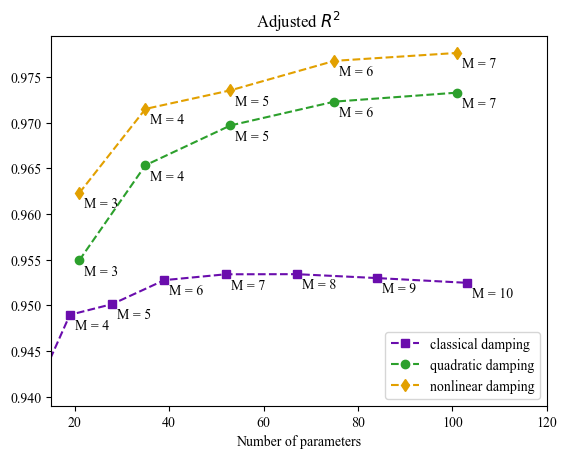

In [224]:
fig, ax = plt.subplots()
sub_df = df1[df1['kind'] == 'classical']
N1 = sub_df['N'].to_numpy()
M1 = sub_df['M'].to_numpy()
y1 = sub_df['RSQR_ADJ'].to_numpy()
ax.plot(N1, y1, label='classical damping',marker='s', linestyle='dashed')
sub_df = df1[df1['kind'] == 'generalized']
N2 = sub_df['N'].to_numpy()
M2 = sub_df['M'].to_numpy()
y2 = sub_df['RSQR_ADJ'].to_numpy()
ax.plot(N2, y2, label='quadratic damping',marker='o', linestyle='dashed')
sub_df = df1[df1['kind'] == 'nonlinear']
N3 = sub_df['N'].to_numpy()
M3 = sub_df['M'].to_numpy()
y3 = sub_df['RSQR_ADJ'].to_numpy()
ax.plot(N3,y3, label='nonlinear damping',marker='d', linestyle='dashed')

for i, N in enumerate(N1):
    ax.annotate(f'M = {M1[i]}', (N1[i],y1[i]), xytext=(5,-15), xycoords='data', textcoords='offset pixels')
for i, N in enumerate(N2):
    ax.annotate(f'M = {M2[i]}', (N2[i],y2[i]), xytext=(5,-15), xycoords='data', textcoords='offset pixels')
for i, N in enumerate(N3):
    ax.annotate(f'M = {M3[i]}', (N3[i],y3[i]), xytext=(5,-15), xycoords='data', textcoords='offset pixels')
ax.set_xlim(15,120)
plt.legend()
plt.xlabel('Number of parameters')
plt.title(r'Adjusted $R^2$')

Text(0.5, 1.0, 'RMSE')

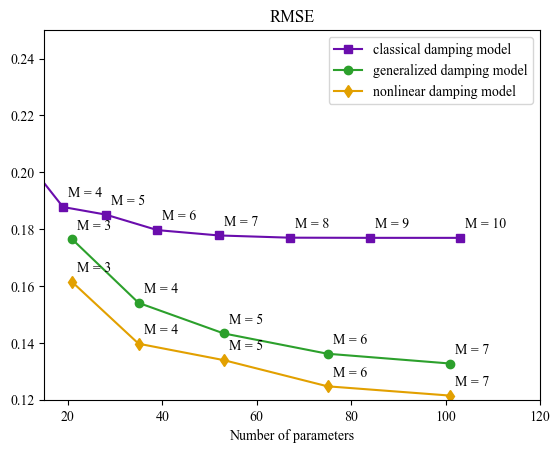

In [212]:
fig, ax = plt.subplots()
sub_df = df1[df1['kind'] == 'classical']
N1 = sub_df['N'].to_numpy()
M1 = sub_df['M'].to_numpy()
y1 = sub_df['RMSE'].to_numpy()
ax.plot(N1, y1, label='classical damping model',marker='s')
sub_df = df1[df1['kind'] == 'generalized']
N2 = sub_df['N'].to_numpy()
M2 = sub_df['M'].to_numpy()
y2 = sub_df['RMSE'].to_numpy()
ax.plot(N2, y2, label='generalized damping model',marker='o')
sub_df = df1[df1['kind'] == 'nonlinear']
N3 = sub_df['N'].to_numpy()
M3 = sub_df['M'].to_numpy()
y3 = sub_df['RMSE'].to_numpy()
ax.plot(N3,y3, label='nonlinear damping model',marker='d')

for i, N in enumerate(N1):
    ax.annotate(f'M = {M1[i]}', (N1[i],y1[i]), xytext=(5,10), xycoords='data', textcoords='offset pixels')
for i, N in enumerate(N2):
    ax.annotate(f'M = {M2[i]}', (N2[i],y2[i]), xytext=(5,10), xycoords='data', textcoords='offset pixels')
for i, N in enumerate(N3):
    ax.annotate(f'M = {M3[i]}', (N3[i],y3[i]), xytext=(5,10), xycoords='data', textcoords='offset pixels')
ax.set_xlim(15,120)
ax.set_ylim(.12,.25)
plt.legend()
plt.xlabel('Number of parameters')
plt.title('RMSE')

Text(0.5, 1.1, 'Model Performance Comparison')

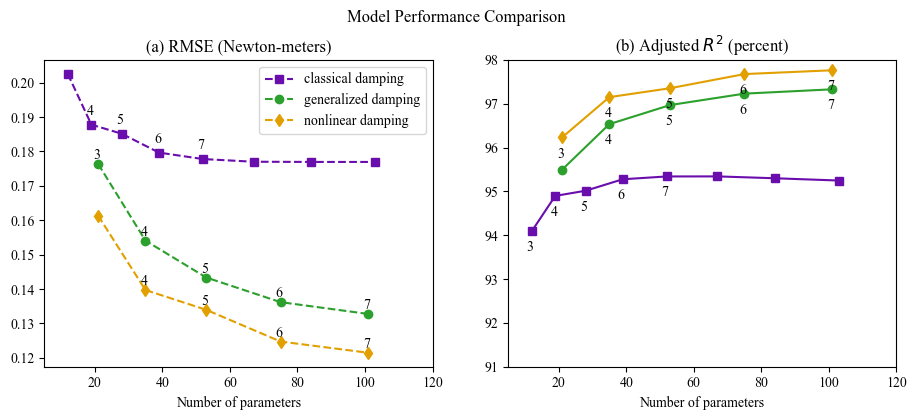

In [226]:
# RMSE / Adjusted R^2 plot combined
fig, axs = plt.subplots(1,2,sharex=True)
fig.tight_layout()
fig.set_figheight(3.5)
fig.set_figwidth(9.5)
sub_df = df1[df1['kind'] == 'classical']
N1 = sub_df['N'].to_numpy()
M1 = sub_df['M'].to_numpy()
y1 = sub_df['RMSE'].to_numpy()
axs[0].plot(N1, y1, label='classical damping',marker='s', linestyle='dashed')
sub_df = df1[df1['kind'] == 'generalized']
N2 = sub_df['N'].to_numpy()
M2 = sub_df['M'].to_numpy()
y2 = sub_df['RMSE'].to_numpy()
axs[0].plot(N2, y2, label='generalized damping',marker='o', linestyle='dashed')
sub_df = df1[df1['kind'] == 'nonlinear']
N3 = sub_df['N'].to_numpy()
M3 = sub_df['M'].to_numpy()
y3 = sub_df['RMSE'].to_numpy()
axs[0].plot(N3,y3, label='nonlinear damping',marker='d', linestyle='dashed')

for i, N in enumerate(N1):
    if M1[i] in [4,5,6,7]:
        # if i < 3:
        axs[0].annotate(f'{M1[i]}', (N1[i],y1[i]), xytext=(-5,10), xycoords='data', textcoords='offset pixels')
        # else:
            # axs[0].annotate(f'M = {M1[i]}', (N1[i],y1[i]), xytext=(-5,-20), xycoords='data', textcoords='offset pixels')
for i, N in enumerate(N2):
    axs[0].annotate(f'{M2[i]}', (N2[i],y2[i]), xytext=(-5,5), xycoords='data', textcoords='offset pixels')

for i, N in enumerate(N3):
    if M3[i] > 3:
        axs[0].annotate(f'{M3[i]}', (N3[i],y3[i]), xytext=(-5,5), xycoords='data', textcoords='offset pixels')

axs[0].set_xlim(15,120)
axs[0].legend()
axs[0].set_xlabel('Number of parameters')
axs[0].set_title('(a) RMSE (Newton-meters)')

sub_df = df1[df1['kind'] == 'classical']
N1 = sub_df['N'].to_numpy()
M1 = sub_df['M'].to_numpy()
y1 = 100*sub_df['RSQR_ADJ'].to_numpy()
axs[1].plot(N1, y1, label='classical damping',marker='s')
sub_df = df1[df1['kind'] == 'generalized']
N2 = sub_df['N'].to_numpy()
M2 = sub_df['M'].to_numpy()
y2 = 100*sub_df['RSQR_ADJ'].to_numpy()
axs[1].plot(N2, y2, label='quadratic damping',marker='o')
sub_df = df1[df1['kind'] == 'nonlinear']
N3 = sub_df['N'].to_numpy()
M3 = sub_df['M'].to_numpy()
y3 = 100*sub_df['RSQR_ADJ'].to_numpy()
axs[1].plot(N3,y3, label='nonlinear damping',marker='d')

for i, N in enumerate(N1):
    if M1[i] in [3,4,5,6,7]:
        axs[1].annotate(f'{M1[i]}', (N1[i],y1[i]), xytext=(-5,-20), xycoords='data', textcoords='offset pixels')
for i, N in enumerate(N2):
    if M2[i] > 3:
        axs[1].annotate(f'{M2[i]}', (N2[i],y2[i]), xytext=(-5,-20), xycoords='data', textcoords='offset pixels')
for i, N in enumerate(N3):
    axs[1].annotate(f'{M3[i]}', (N3[i],y3[i]), xytext=(-5,-20), xycoords='data', textcoords='offset pixels')
axs[1].set_xlim(5,120)
axs[1].set_ylim(91,98)
# axs[1].legend()
axs[1].set_xlabel('Number of parameters')
axs[1].set_title(r'(b) Adjusted $R^2$ (percent)')
fig.suptitle('Model Performance Comparison',x=.5,y=1.1)

Text(0.5, 1.0, 'Bayes Information Criterion')

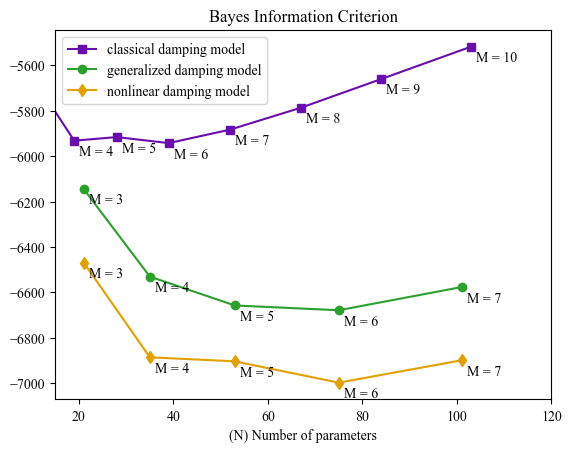

In [214]:
fig, ax = plt.subplots()
sub_df = df1[df1['kind'] == 'classical']
N1 = sub_df['N'].to_numpy()
M1 = sub_df['M'].to_numpy()
y1 = sub_df['BIC'].to_numpy()
ax.plot(N1, y1, label='classical damping model',marker='s')
sub_df = df1[df1['kind'] == 'generalized']
N2 = sub_df['N'].to_numpy()
M2 = sub_df['M'].to_numpy()
y2 = sub_df['BIC'].to_numpy()
ax.plot(N2, y2, label='generalized damping model',marker='o')
sub_df = df1[df1['kind'] == 'nonlinear']
N3 = sub_df['N'].to_numpy()
M3 = sub_df['M'].to_numpy()
y3 = sub_df['BIC'].to_numpy()
ax.plot(N3,y3, label='nonlinear damping model',marker='d')

for i, N in enumerate(N1):
    ax.annotate(f'M = {M1[i]}', (N1[i],y1[i]), xytext=(5,-15), xycoords='data', textcoords='offset pixels')
for i, N in enumerate(N2):
    ax.annotate(f'M = {M2[i]}', (N2[i],y2[i]), xytext=(5,-15), xycoords='data', textcoords='offset pixels')
for i, N in enumerate(N3):
    ax.annotate(f'M = {M3[i]}', (N3[i],y3[i]), xytext=(5,-15), xycoords='data', textcoords='offset pixels')
ax.set_xlim(15,120)
plt.legend()
plt.xlabel('(N) Number of parameters')
plt.title('Bayes Information Criterion')

Text(0.5, 1.0, 'Akaike Information Criterion')

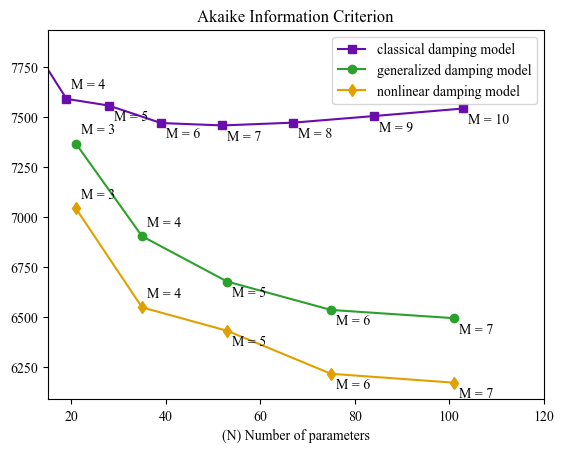

In [215]:
fig, ax = plt.subplots()
sub_df = df1[df1['kind'] == 'classical']
N1 = sub_df['N'].to_numpy()
M1 = sub_df['M'].to_numpy()
y1 = sub_df['AIK'].to_numpy()
ax.plot(N1, y1, label='classical damping model',marker='s')
sub_df = df1[df1['kind'] == 'generalized']
N2 = sub_df['N'].to_numpy()
M2 = sub_df['M'].to_numpy()
y2 = sub_df['AIK'].to_numpy()
ax.plot(N2, y2, label='generalized damping model',marker='o')
sub_df = df1[df1['kind'] == 'nonlinear']
N3 = sub_df['N'].to_numpy()
M3 = sub_df['M'].to_numpy()
y3 = sub_df['AIK'].to_numpy()
ax.plot(N3,y3, label='nonlinear damping model',marker='d')

for i, N in enumerate(N1):
    if i < 2:
        ax.annotate(f'M = {M1[i]}', (N1[i],y1[i]), xytext=(5,10), xycoords='data', textcoords='offset pixels')
    else:
        ax.annotate(f'M = {M1[i]}', (N1[i],y1[i]), xytext=(5,-15), xycoords='data', textcoords='offset pixels')
for i, N in enumerate(N2):
    if i < 2:
        ax.annotate(f'M = {M2[i]}', (N2[i],y2[i]), xytext=(5,10), xycoords='data', textcoords='offset pixels')
    else:
        ax.annotate(f'M = {M2[i]}', (N2[i],y2[i]), xytext=(5,-15), xycoords='data', textcoords='offset pixels')
for i, N in enumerate(N3):
    if i < 2:
        ax.annotate(f'M = {M3[i]}', (N3[i],y3[i]), xytext=(5,10), xycoords='data', textcoords='offset pixels')
    else:
        ax.annotate(f'M = {M3[i]}', (N3[i],y3[i]), xytext=(5,-15), xycoords='data', textcoords='offset pixels')
ax.set_xlim(15,120)
plt.legend()
plt.xlabel('(N) Number of parameters')
plt.title('Akaike Information Criterion')

Text(0.5, 1.0, 'Nested Model Liklihood Ratio Test')

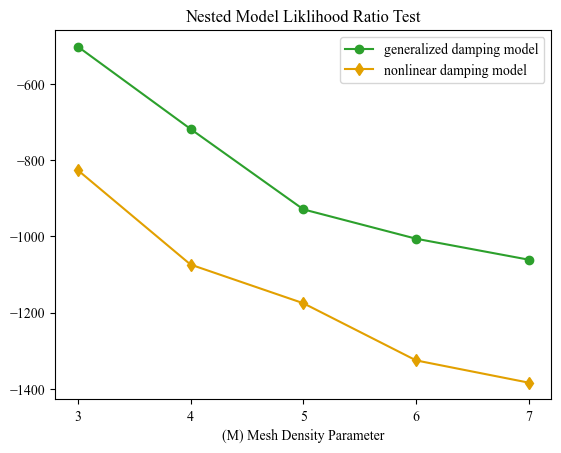

In [216]:
# liklihood ratio test for nested models
# derived from delta AIC, e.g., Q = 2*log(B)-2*log(A) for A nested in B
# and AIC(B)-AIC(A) = Q + 2(p_a-p_b)
n_samples = generalized_models[0].sample_size
classical_df = df2[df2['kind'] == 'classical']
generalized_df = df2[df2["kind"] == 'generalized']
nonlinear_df = df2[df2["kind"] == 'nonlinear']

p1 = classical_df['N'].to_numpy()
p2 = generalized_df['N'].to_numpy()
p3 = nonlinear_df['N'].to_numpy()
AIC1 = classical_df['AIK'].to_numpy()
AIC2 = generalized_df['AIK'].to_numpy()
AIC3 = nonlinear_df['AIK'].to_numpy()
LRT21 = np.array([AIC2[i]-AIC1[i]+2*(p1[i]-p2[i]) for i in range(len(p1))])
LRT31 = np.array([AIC3[i]-AIC1[i]+2*(p1[i]-p3[i]) for i in range(len(p1))])
plt.xticks(classical_df['M'])
plt.plot()
plt.plot(classical_df['M'],LRT21, label='generalized damping model', marker='o', color='C1')
plt.plot(classical_df['M'],LRT31, label='nonlinear damping model', marker='d', color='C2')
plt.legend()
plt.xlabel('(M) Mesh Density Parameter')
plt.title('Nested Model Liklihood Ratio Test')

Text(0.5, 1.0, 'Akaike Information Loss vs Bayesian Information Criterion')

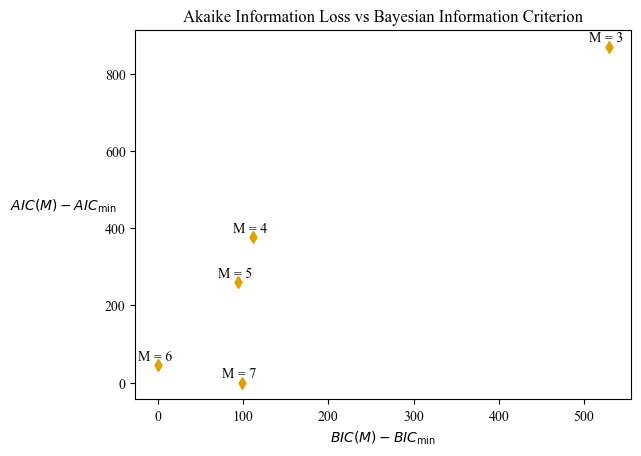

In [217]:
xdata,ydata = nonlinear_df['BIC'].to_numpy(), nonlinear_df['AIK'].to_numpy()
BIC_MIN = np.min(xdata)
AIK_MIN = np.min(ydata)
xdata = xdata-BIC_MIN
ydata = ydata-AIK_MIN
fig,ax = plt.subplots()
ax.scatter(xdata, ydata, color='C2', marker='d')
for i in range(len(nonlinear_df)):
    M = nonlinear_df.iloc[i]['M']
    ax.annotate(f'M = {M}', (xdata[i],ydata[i]), xytext=(-20,5), xycoords='data', textcoords='offset pixels')

plt.xlabel(r"$BIC(M) - BIC_\text{min}$")
plt.ylabel(r"$AIC(M) - AIC_\text{min}$",rotation=0, labelpad=30)
plt.title('Akaike Information Loss vs Bayesian Information Criterion')

Text(0.5, 1.0, 'Nonlinear Damping AIC vs Liklihood Ratio')

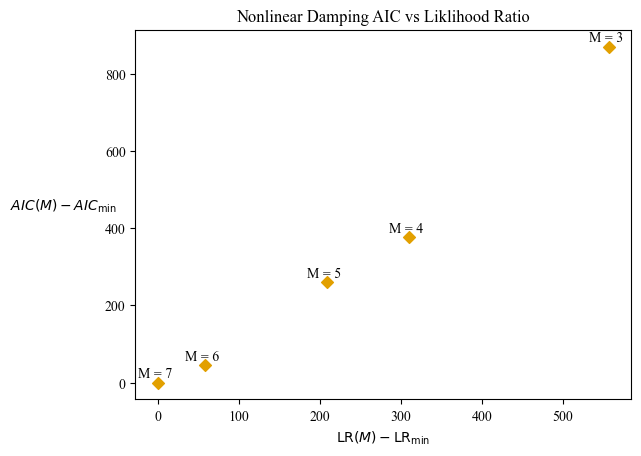

In [218]:
xdata,ydata = LRT31, nonlinear_df['AIK'].to_numpy()
LRT_MIN = np.min(xdata)
AIK_MIN = np.min(ydata)
xdata = xdata-LRT_MIN
ydata = ydata-AIK_MIN
fig,ax = plt.subplots()
ax.scatter(xdata,ydata,color='C2',marker='D')
for i in range(len(nonlinear_df)):
    M = nonlinear_df.iloc[i]['M']
    ax.annotate(f'M = {M}', (xdata[i],ydata[i]), xytext=(-20,5), xycoords='data', textcoords='offset pixels')
ax.set_xlabel(r'$\text{LR}(M) - \text{LR}_\text{min}$')
ax.set_ylabel(r'$AIC(M) - AIC_\text{min}$', rotation=0, labelpad=30)
ax.set_title('Nonlinear Damping AIC vs Liklihood Ratio')

In [219]:
# organize a DF to summarize test statistics for generalized and nonlinear
columns=['N','M','kind','RMSE', 'RSQR_ADJ', 'AIK', 'BIC', 'LRT']
classical_df = df2[df2['kind'] == 'classical']
generalized_df = df2[df2['kind'] == 'generalized']
nonlinear_df = df2[df2['kind'] == 'nonlinear']
sub_df = df2[df2['kind'] != 'classical']
table_df = pd.DataFrame()
print(table_df.columns)

p1 = {row['M'] : row['N'] for loc, row in classical_df.iterrows()}
AIC1 = {row['M'] : row['AIK']-AIK_MIN for loc, row in classical_df.iterrows()}
p2 = {row['M'] : row['N'] for loc, row in generalized_df.iterrows()}
AIC2 = {row['M'] : row['AIK']-AIK_MIN for loc, row in generalized_df.iterrows()}
p3 = {row['M'] : row['N'] for loc, row in nonlinear_df.iterrows()}
AIC3 = {row['M'] : row['AIK']-AIK_MIN for loc, row in nonlinear_df.iterrows()}
for column_loc,key in enumerate(columns):
    if key != 'LRT':
        table_df.insert(column_loc, key, sub_df[key])
    else:
        LRT = []
        for row_loc, row in table_df.iterrows():
            kind, M, N = row['kind'], row['M'], row['N']
            if kind == 'generalized':
                LRT.append(AIC2[M]-AIC1[M]+2*(p1[M] - p2[M]))
            else:
                LRT.append(AIC3[M]-AIC1[M]+2*(p1[M] - p3[M]))
        table_df.insert(column_loc, key, LRT)

float_format = lambda x: f"{int(x)}" if abs(x) > 1 else f"{x:0.03f}"
print(table_df.to_csv(float_format=float_format))

RangeIndex(start=0, stop=0, step=1)
,N,M,kind,RMSE,RSQR_ADJ,AIK,BIC,LRT
8,21,3,generalized,0.176,0.955,7367,-6144,-502
9,35,4,generalized,0.154,0.965,6904,-6530,-718
10,53,5,generalized,0.143,0.970,6678,-6657,-929
11,75,6,generalized,0.136,0.972,6536,-6678,-1006
12,101,7,generalized,0.133,0.973,6495,-6576,-1061
13,21,3,nonlinear,0.161,0.962,7043,-6468,-826
14,35,4,nonlinear,0.140,0.972,6549,-6886,-1074
15,53,5,nonlinear,0.134,0.974,6432,-6903,-1175
16,75,6,nonlinear,0.125,0.977,6217,-6997,-1325
17,101,7,nonlinear,0.121,0.978,6172,-6899,-1383



(11.0, 18.5)

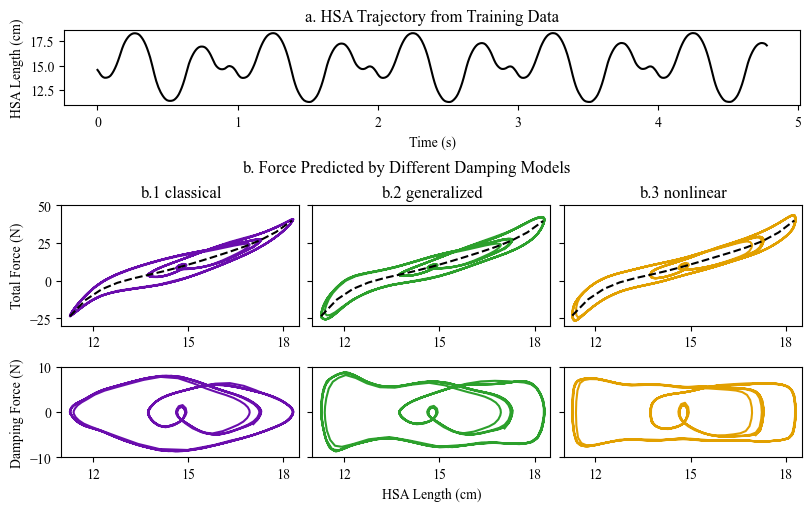

In [220]:
# plot to compare Force/Length for different values of psi under the chosen model (nonlinear, M=6)
from matplotlib.gridspec import GridSpec
from scipy.stats import norm
supfig = plt.figure(layout='constrained', figsize=(8,5))
figs = supfig.subfigures(nrows=3,ncols=1,height_ratios=([.3,.4,.3]))

# get the data
psi_idx = i = 0
psi_value = psi[i]
l_min = np.min(l[i])
l_max = np.max(l[i])
start_idx = 0
stop_idx = len(l[i])
l_linspace = np.arange(l_min, l_max, .005)
model1 = classical_models[2].model
model2 = generalized_models[2].model
model3 = nonlinear_models[2].model

# plot trajectory of training data
axstop = figs[0].subplots()
axstop.plot(t[i]-t[i][0],100*l[i],color='black')
# axstop.plot(t[i][1:-1]-t[i][0],100*ldot,color='black')
axstop.set_xlabel('Time (s)')
axstop.set_ylabel('HSA Length (cm)')
axstop.set_title('a. HSA Trajectory from Training Data')

# calculate elastic force and plot in 1x3 subfig with sharex and sharey
axsmid = figs[1].subplots(1,3,sharex=True,sharey=True)
elastic_force1 = np.array([model1.dV([l[i][j],psi[i]]) for j in range(start_idx,stop_idx)])
damp_force1 = np.array([model1.dR([l[i][j],psi[i]],[ldot[i][j],0]) for j in range(start_idx,stop_idx)])
elastic_force_dashed1 = np.array([model1.dV([_l,psi[i]]) for _l in l_linspace])
axsmid[0].plot(100*l[i][start_idx:stop_idx],elastic_force1+damp_force1,color='C0')
axsmid[0].plot(100*l_linspace,elastic_force_dashed1,color='black', linestyle='dashed')
axsmid[0].set_title('b.1 classical')
figs[1].suptitle('b. Force Predicted by Different Damping Models')

elastic_force2 = np.array([model2.dV([l[i][j],psi[i]]) for j in range(start_idx,stop_idx)])
damp_force2 = np.array([model2.dR([l[i][j],psi[i]],[ldot[i][j],0]) for j in range(start_idx,stop_idx)])
elastic_force_dashed2 = np.array([model2.dV([_l,psi[i]]) for _l in l_linspace])
axsmid[1].plot(100*l[i][start_idx:stop_idx],elastic_force2+damp_force2,color='C1')
axsmid[1].plot(100*l_linspace,elastic_force_dashed2,color='black', linestyle='dashed')
axsmid[1].set_title('b.2 generalized')

elastic_force3 = np.array([model3.dV([l[i][j],psi[i]]) for j in range(start_idx,stop_idx)])
damp_force3 = np.array([model3.dR([l[i][j],psi[i]],[ldot[i][j],0]) for j in range(start_idx,stop_idx)])
elastic_force_dashed3 = np.array([model3.dV([_l,psi[i]]) for _l in l_linspace])
axsmid[2].plot(100*l[i][start_idx:stop_idx],elastic_force3+damp_force3,color='C2')
axsmid[2].plot(100*l_linspace,elastic_force_dashed3,color='black', linestyle='dashed')
axsmid[2].set_title('b.3 nonlinear')
axsmid[0].set_ylim(-30,50)
axsmid[0].set_yticks([-25,0,25,50])
axsmid[0].set_ylabel('Total Force (N)')
axsmid[0].set_xticks([12,15,18])
axsmid[0].set_xlim((11,18.5))

# now damping force plots
axsbot = figs[2].subplots(1,3,sharex=True,sharey=True)
axsbot[0].plot(100*l[i][start_idx:stop_idx],damp_force1,color='C0')
axsbot[1].plot(100*l[i][start_idx:stop_idx],damp_force2,color='C1')
axsbot[2].plot(100*l[i][start_idx:stop_idx],damp_force3,color='C2')
axsbot[1].set_xlabel('HSA Length (cm)')
axsbot[0].set_ylabel('Damping Force (N)')
axsbot[0].set_ylim(-10,10)
axsbot[0].set_xticks([12,15,18])
axsbot[0].set_xlim((11,18.5))

# axsfinal = figs[3].subplots(1,3,sharex=True,sharey=True)
# errors1 = classical_models[3].errors
# errors2 = generalized_models[3].errors
# errors3 = nonlinear_models[3].errors
# all_errors = np.hstack((errors1,errors2,errors3))
# sigma = np.std(all_errors)
# rv_params1 = norm.fit(errors1)
# axsfinal[0].hist(errors1, range=(-3*sigma,3*sigma), bins=20, density=True)
# axsfinal[1].hist(errors2, range=(-3*sigma,3*sigma), bins=20, density=True)
# axsfinal[2].hist(errors3, range=(-3*sigma,3*sigma), bins=20, density=True)


In [231]:
plt.plot(ldot[i],damp_force3*ldot[i])

IndexError: list index out of range